Ana Lúcia Ferreira, up202105838

Ayrton Da Cryz, up202300120

In [45]:
import os
from google.colab.patches import cv2_imshow

In [46]:
!rm -rf VCOMP_assignment1_dataset
!git clone https://github.com/LuciaFerr/VCOMP_assignment1_dataset.git
dataset_path = "VCOMP_assignment1_dataset"
print(os.listdir(dataset_path))

Cloning into 'VCOMP_assignment1_dataset'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 170 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 52.24 MiB | 30.36 MiB/s, done.
Resolving deltas: 100% (14/14), done.
['.git', 'Kit', 'Calibration', 'Fault', 'Isolated']


In [47]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd

calibrationDir1 = os.path.join(dataset_path, "Calibration", "calib1")
calibrationDir2 = os.path.join(dataset_path, "Calibration", "calib2")
calibrationDir3 = os.path.join(dataset_path, "Calibration", "calib3")

background = os.path.join(dataset_path, "Calibration", "background.png")

images1 = glob.glob(os.path.join(calibrationDir1, "*.png"))
images2 = glob.glob(os.path.join(calibrationDir2, "*.png"))
images3 = glob.glob(os.path.join(calibrationDir3, "*.png"))

final_setup = os.path.join(dataset_path, "Calibration", "final_setup.png")
colored_bricks = os.path.join(dataset_path, "Isolated", "colored_bricks.png")

# **1- Calibration Images**

**(a) Three intrinsic calibration attempts were made to determine the intrinsic parameters and lens distortion of the camera. The calibration attempts are contained
in folders Calib1, Calib2 and Calib3. For each attempt, present the intrinsic matrix, the lens distortion coefficients and the re-projection error. Select the best
calibration**

In [48]:
def calibrate_camera(folder):

  # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
  objp = np.zeros((11*8,3), np.float32)
  objp[:,:2] = np.mgrid[0:11,0:8].T.reshape(-1,2)

  # Arrays to store object points and image points from all the images.
  objpoints = [] # 3d point in real world space
  imgpoints = [] # 2d points in image plane.
  img_shape = None # Initialize img_shape to store the image dimensions

  images = glob.glob(os.path.join(folder, "*.png"))

  if not images: # Check if no images were found
      print(f"No images found in {folder}. Cannot perform calibration.")
      return None, None, float('inf') # Return indicating failure

  for fname in images:
    imgBGR = cv2.imread(fname)
    if imgBGR is None: # Handle cases where image reading fails
        print(f"Warning: Could not read image {fname}. Skipping.")
        continue

    imgGray = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2GRAY)
    if img_shape is None: # Store shape from the first valid image encountered
        img_shape = imgGray.shape[::-1] # (width, height) for calibrateCamera

    CornersFound, cornerOrg = cv2.findChessboardCorners(imgGray,(11,8), None)

    if CornersFound == True:
      objpoints.append(objp)
      cornersRefined = cv2.cornerSubPix(imgGray, cornerOrg, (11,11), (-1,-1),(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,30,0.001))
      imgpoints.append(cornersRefined)

      # For visualization during debugging, uncomment these lines:
      # cv2.drawChessboardCorners(imgBGR, (11,8), cornersRefined, CornersFound)
      # cv2_imshow(imgBGR)

  if not objpoints: # If no chessboard corners were found in any image
      print(f"No chessboard corners found in any images in {folder}. Cannot perform calibration.")
      return None, None, float('inf')

  #calibration
  ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    img_shape, # Use the stored img_shape
    None,
    None
  )

  #Reprojection Error
  mean_error = 0
  for i in range(len(objpoints)):
      imgpoints2, _ = cv2.projectPoints(
          objpoints[i], #pontos 3D reais do tabuleiro
          rvecs[i],
          tvecs[i],
          K,
          dist
      )
      #imgpoints: pontos 2D - corners refined (pontos reais detetados pela câmera)
      #imgpoints2: pontos previstos pelo modelo da câmera
      error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
      mean_error += error

  reprojection_error = mean_error / len(objpoints)


  return K, dist, reprojection_error

In [49]:
folders = [calibrationDir1, calibrationDir2, calibrationDir3]
results = []
for i, folder in enumerate(folders):

    print("\nCalibration", i+1)
    K, dist, error = calibrate_camera(folder)
    results.append((i+1, K, dist, error))

    print("\n Intrinsic matrix:")
    print(K)
    print("\nDistortion:", dist)
    print("\nReprojection error:", error)

best = min(results, key=lambda x: x[3])
print("\n\n")
print("Best Calibration set: ",best[0])
print("Reprojection Error: ", best[3])


Calibration 1

 Intrinsic matrix:
[[827.57846602   0.         334.83393111]
 [  0.         827.43749443 281.31040706]
 [  0.           0.           1.        ]]

Distortion: [[-0.43653613  0.40330685 -0.00135039  0.00154944 -0.53357973]]

Reprojection error: 0.04035182295435243

Calibration 2

 Intrinsic matrix:
[[839.07613864   0.         339.34165722]
 [  0.         839.32227716 276.31089839]
 [  0.           0.           1.        ]]

Distortion: [[-4.32166092e-01  2.83162021e-01 -2.23953392e-04  4.15173865e-04
  -1.38440668e-01]]

Reprojection error: 0.007449464280874494

Calibration 3

 Intrinsic matrix:
[[837.55334665   0.         338.4458338 ]
 [  0.         837.739777   276.54574909]
 [  0.           0.           1.        ]]

Distortion: [[-4.45524980e-01  3.95182930e-01 -4.52500341e-04  2.07671941e-04
  -4.44969712e-01]]

Reprojection error: 0.015440094917720942



Best Calibration set:  2
Reprojection Error:  0.007449464280874494


Re-projection error gives a good estimation of just how exact the found parameters are. The closer the re-projection error is to zero, the more accurate the parameters we found are.

Calibration attempt Calib2 was selected because it produced the lowest reprojection error (0.0074 pixels) among the three calibration sets, indicating a more accurate estimation of the camera parameters.


**(b) The image ”final setup.png” represents the final inspection arrangement. Calibrate the extrinsic parameters of the camera setup. Present the extrinsic matrix and specify the pixel-to-millimeter conversion factor applied.**

In [50]:
def extrinsic_calibration(image_path, K, dist):

    # Definir pontos reais (em mm)
    square_size = 15  # mm (do enunciado)

    objp = np.zeros((11*8, 3), np.float32)
    objp[:, :2] = np.mgrid[0:11, 0:8].T.reshape(-1, 2)
    objp *= square_size

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #  Detectar cantos
    ret, corners = cv2.findChessboardCorners(gray, (11, 8), None)

    if not ret:
        print("Chessboard not detected!")
        return None

    # Refinar cantos
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners_refined = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

    # Resolver PnP (extrínsecos)
    ret, rvec, tvec = cv2.solvePnP(objp, corners_refined, K, dist)

    #  Converter rotação
    R, _ = cv2.Rodrigues(rvec)

    #  Matriz extrínseca
    extrinsic = np.hstack((R, tvec))

    # Fator pixel -> mm
    pixel_dist = np.linalg.norm(corners_refined[0] - corners_refined[1])
    real_dist = square_size
    #print("\n\nPixel distance in mm: ", pixel_dist)

    scale = real_dist / pixel_dist #scale -> quantos mm são a distância entre 2 pixeis

    return extrinsic, scale

To estimate the extrinsic parameters of the camera, a chessboard pattern with known square dimensions (15 mm) was used. The 3D coordinates of the chessboard corners were defined in the real-world reference frame, and the corresponding 2D image points were detected using corner detection. These points were refined for higher accuracy.

The extrinsic parameters were then obtained by solving the Perspective-n-Point (PnP) problem, resulting in the rotation and translation vectors, which were combined into the extrinsic matrix.

Additionally, a pixel-to-millimeter conversion factor was computed by comparing the distance between two adjacent detected corners in pixels with the known real-world distance between them.

In [51]:
extrinsic, scale = extrinsic_calibration(final_setup,K,dist)

print("Matriz extrínseca [R | t]:\n", extrinsic)

print("\n\nEscala (mm/pixel): ", scale)


Matriz extrínseca [R | t]:
 [[-9.98478284e-01 -1.21212791e-02 -5.37976937e-02  6.44527592e+01]
 [ 8.67155268e-03 -9.97918607e-01  6.39003778e-02  3.55994685e+01]
 [-5.44602739e-02  6.33366300e-02  9.96505168e-01  2.66030766e+02]]


Escala (mm/pixel):  0.34302127


#**2- Isolated Brick Images**


**(a) Define a ROI (region of interest) for the image**

A region of interest (ROI) was defined by first converting the image to grayscale and applying Otsu thresholding to segment the foreground. The bounding box of the detected foreground pixels was then computed, and the image was cropped accordingly to isolate the relevant region.

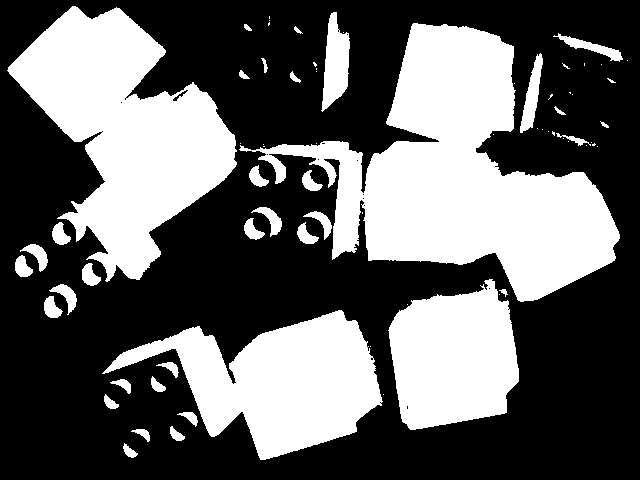

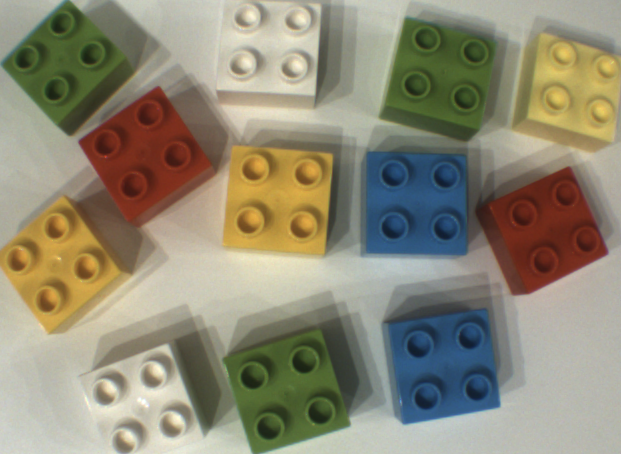

In [52]:
img_bgr = cv2.imread(colored_bricks)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
cv2_imshow(thresh)
coords = cv2.findNonZero(thresh)
x, y, w, h = cv2.boundingRect(coords)

roi = img_bgr[y:y+h, x:x+w]
cv2_imshow(roi)


**(b) For image ”colored bricks.png”, count the number of bricks grouped by color.**

In [53]:
lower_blue = np.array([90, 80, 50])
upper_blue = np.array([130, 255, 255])

lower_green = np.array([35, 50, 80])
upper_green = np.array([85, 255, 255])

lower_red1 = np.array([0, 150, 80])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 150, 80])
upper_red2 = np.array([179, 255, 255])

lower_yellow = np.array([15, 100, 120])
upper_yellow = np.array([40, 255, 255])

The following function aims to count the number of bricks by color.

For colored bricks, the method is based on segmentation in the HSV color space. Initially, masks are defined for each target color, allowing the isolation of the corresponding pixels. Morphological operations (such as opening and closing) are then applied to remove noise and improve the quality of the masks. Finally, the function connectedComponentsWithStats is used to identify connected components and count the number of objects in each mask, corresponding to the number of bricks of each color.

In the case of white bricks, this approach alone was not effective. Since the background of the image is also white, color-based segmentation produces a mask that includes both the bricks and the background, making it difficult to correctly separate the objects. Edge detection techniques such as Canny and Sobel were also tested, but they did not provide satisfactory results, as the intensity differences between the white bricks and the background are minimal.

Therefore, a complementary approach was applied on the white mask itself. Although this mask captures a significant portion of the background, the HoughCircles function was used to detect the circular studs characteristic of LEGO bricks within the relevant regions. This made it possible to identify only the bricks while effectively ignoring the background. The detected circles were then spatially grouped, allowing each brick to be identified individually and, consequently, enabling the counting of white bricks.

The fact that the background is white posed a significant challenge, requiring the combination of color-based segmentation with geometric feature detection.

In [54]:

from sklearn.cluster import DBSCAN
def count_by_color(image):

  hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)


  # dicionário de cores
  colors = {
      "blue": (lower_blue, upper_blue),
      "green": (lower_green, upper_green),
      "yellow": (lower_yellow, upper_yellow)
      }

  kernel = np.ones((5,5), np.uint8)

  results = {}
  masks = {}
  white_boxes = []

  for color, (lower, upper) in colors.items():

        mask = cv2.inRange(hsv_img, lower, upper)

        # limpar máscara
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.erode(mask, kernel, iterations=1)
        masks[color] = mask

        #plt.imshow(mask, cmap='gray')
        #plt.show()
        #plt.title(color)


        # Obter numero de peças
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

        min_area = 500
        count = 0

        for i in range(1, num_labels):  # ignorar fundo (começa em 1)
          area = stats[i, cv2.CC_STAT_AREA]
          #print(area)

          if area > min_area:
              count += 1


        results[color] = count


############### vermelho (combinar duas máscaras) ################
  mask_red1 = cv2.inRange(hsv_img, lower_red1, upper_red1)
  mask_red2 = cv2.inRange(hsv_img, lower_red2, upper_red2)

  mask_red = cv2.bitwise_or(mask_red1, mask_red2)
  mask_red = cv2.morphologyEx(mask_red, cv2.MORPH_OPEN, kernel)
  mask_red = cv2.morphologyEx(mask_red, cv2.MORPH_CLOSE, kernel)
  masks["red"] = mask_red
  #plt.imshow(mask_red, cmap='gray')
  #plt.show()
  #plt.title("red")


  num_labels, _, stats, _ = cv2.connectedComponentsWithStats(mask_red)
  count = 0

  for i in range(1, num_labels):  # ignorar fundo (começa em 1)
    area = stats[i, cv2.CC_STAT_AREA]
    if area > min_area:
      count += 1

  results["red"] = count

######################## WHITE ##############################
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  gray = cv2.equalizeHist(gray)
  blur = cv2.GaussianBlur(gray, (7,7), 1.5)

  _, mask_white = cv2.threshold(blur, 225, 255, cv2.THRESH_BINARY) #214?

  #plt.imshow(mask_white, cmap='gray')
  #plt.title("white mask")
  #plt.show()

  masked = cv2.bitwise_and(gray, gray, mask=mask_white)
  blur2 = cv2.GaussianBlur(masked, (9,9), 1.5)
  #plt.imshow(blur2, cmap='gray')
  #plt.title("white mask after bitwise")
  #plt.show()

################ IDENTIFICAR CIRCULOS #################3
  circles = cv2.HoughCircles(
      blur2,
      cv2.HOUGH_GRADIENT,
      dp=1,
      minDist=20,
      param1=50,
      param2=16,
      minRadius=5,
      maxRadius=15
  )

  if circles is None:
    #print("Nenhum círculo detetado")
    results["White"] = 0
  else:

    circles = np.uint16(np.around(circles))
    points = np.array([(x, y) for (x, y, r) in circles[0]])


    output = image.copy()

    for (x, y, r) in circles[0]:
            cv2.circle(output, (x,y), r, (0,255,0), 2)


    #plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    #plt.title("detected circles")
    #plt.show()

    ################## AGRUPAR #########################
    clustering = DBSCAN(eps=60, min_samples=2).fit(points)
    labels = clustering.labels_

    output = image.copy()

    for label in set(labels):

        if label == -1:
            continue

        pts = points[labels == label]

        x_min, y_min = pts.min(axis=0)
        x_max, y_max = pts.max(axis=0)

        pad = 15

        x_min -= pad
        y_min -= pad
        x_max += pad
        y_max += pad

        white_boxes.append((x_min, y_min, x_max, y_max))

        cv2.rectangle(output,
                      (x_min, y_min),
                      (x_max, y_max),
                      (255,0,0), 2)

    #plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    #plt.title("Grouped")
    #plt.show()

    num_pieces = len(set(labels)) - (1 if -1 in labels else 0)
    results["white"] = num_pieces



  return results, masks, white_boxes




In [55]:
results, masks, whites = count_by_color(roi)
for color, count in results.items():
    print(f"{color}: {count}")

blue: 2
green: 3
yellow: 3
red: 2
white: 2


This approach, based on detecting bricks through their studs, was tested as illustrated in the code cell below.

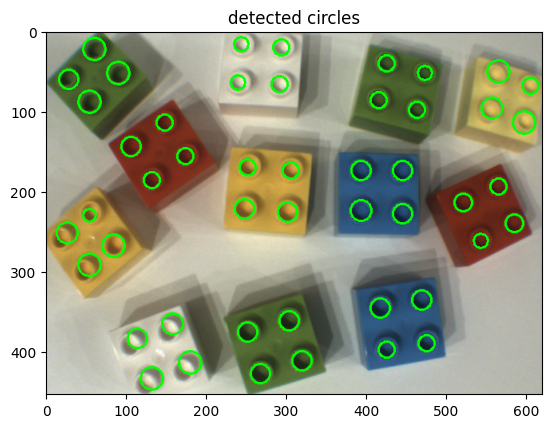

In [56]:
gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (9,9), 1.5)

circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=20,
    param1=50,
    param2=15,
    minRadius=5,
    maxRadius=15
)

output = roi.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))

    for (x, y, r) in circles[0]:
        cv2.circle(output, (x,y), r, (0,255,0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("detected circles")
plt.show()

**C) Consider images ”blue.png”, ”green.png”, ”red.png” and ”yellow.png”. Group the
bricks by size and compute the average area and standard deviation of each
brick size in millimeters.**

In [57]:
blue_bgr = cv2.imread(os.path.join(dataset_path, "Isolated", "blue.png"))
blue_hsv = cv2.cvtColor(blue_bgr, cv2.COLOR_BGR2HSV)

green_bgr = cv2.imread(os.path.join(dataset_path, "Isolated", "green.png"))
green_hsv = cv2.cvtColor(green_bgr, cv2.COLOR_BGR2HSV)

red_bgr = cv2.imread(os.path.join(dataset_path, "Isolated", "red.png"))
red_hsv = cv2.cvtColor(red_bgr, cv2.COLOR_BGR2HSV)

yellow_bgr = cv2.imread(os.path.join(dataset_path, "Isolated", "yellow.png"))
yellow_hsv = cv2.cvtColor(yellow_bgr, cv2.COLOR_BGR2HSV)




In [58]:

def count_sizes_isolated():

  real_areas = {
      "2x1": 32*15, #480 mm^2
      "2x2": 32*32, #1024 mm^2
      "2x4": 32*64, #2048 mm^2
      "2x6": 32*95, #3040 mm^2
      "R2x2": 32*47 #1504 mm^2
  }

  images = {
      "blue": (blue_hsv, lower_blue, upper_blue),
      "green": (green_hsv, lower_green, upper_green),
      "yellow": (yellow_hsv, lower_yellow, upper_yellow),
      "red": (red_hsv, None, None)
  }

  sizes = {k: {"px": [], "mm": []} for k in real_areas.keys()}

  for color, (img_hsv, lower, upper) in images.items():
    #print(f"\n--- {color} ---")

    ######### Identificar cor e tratar das máscaras ###############
    if color == "red":
      mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
      mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
      mask = cv2.bitwise_or(mask1, mask2)
    else:
      mask = cv2.inRange(img_hsv, lower, upper)

    mask = cv2.erode(mask, np.ones((5,5), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel = np.ones((5,5), np.uint8))


########################## CONTOURS #############################
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    debug_img = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    for i, cnt in enumerate(contours):

        # bounding box ROTACIONADA (melhor)
        rect = cv2.minAreaRect(cnt)
        (w, h) = rect[1]
        area_px = w * h

        box = cv2.boxPoints(rect)
        box = np.int32(box)


        #area_px = cv2.contourArea(cnt)
        if area_px < 500: # Changed 'area' to 'area_px'
            continue

          # área em mm
        area_mm = area_px * (scale**2) # Changed 'area' to 'area_px'

          # classificação
        best_match = min(real_areas, key=lambda k: abs(area_mm - real_areas[k]))
        if (w > 50 and w < 85):
          best_match = "2x1"
        if (h > 50 and h < 85):
          best_match = "2x1"
        sizes[best_match]["px"].append(area_px)
        sizes[best_match]["mm"].append(area_mm)


          # centróide
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0

          # desenhar
        cv2.drawContours(debug_img, [box], 0, (0,255,0), 2)
        cv2.circle(debug_img, (cx, cy), 5, (0,0,255), -1)

    #plt.imshow(debug_img, cmap='gray')
    #plt.title(color)
    #plt.show()

  results = []

  for size, data in sizes.items():

      areas_mm = np.array(data["mm"])
      areas_px = np.array(data["px"])

      if len(areas_mm) == 0:
          continue

      avg_mm = np.mean(areas_mm)
      avg_px = np.mean(areas_px)
      std_mm = np.std(areas_mm)

      results.append({
          "Size": size,
          "Avg Area (px)": avg_px,
          "Avg Area (mm)": avg_mm,
          "Std (mm)": std_mm,
          "Quantity": len(areas_mm)
      })

      #print(f"\n{size}:")
      #print(f"  Avg px: {avg_px:.2f}")
      #print(f"  Avg mm: {avg_mm:.2f}")
      #print(f"  Std mm: {std_mm:.2f}")
      #print(f"  Total bricks: {len(areas_mm)}")
  return results


To compute the size of the bricks, color-based masks were first applied to isolate the bricks in each image. Contours were then extracted from the segmented regions, and the area of each brick was estimated using a rotated bounding box.

The computed areas (in mm²) were compared to a set of predefined reference areas, "real_areas", corresponding to known brick sizes. Each detected brick was classified according to the closest reference value.

Finally, for each brick size, the average area and standard deviation were calculated across all images.

In [59]:
results_isolated = count_sizes_isolated()

df = pd.DataFrame(results_isolated)

# ordenar colunas
df = df[["Size", "Avg Area (px)", "Avg Area (mm)", "Std (mm)"]]

# ordenar por tamanho
order = ["2x1", "2x2", "2x4", "2x6", "R2x2"]
df["Size"] = pd.Categorical(df["Size"], categories=order, ordered=True)
df = df.sort_values("Size")
print(df)


   Size  Avg Area (px)  Avg Area (mm)    Std (mm)
0   2x1    6899.094624     811.772217   16.617420
1   2x2    9818.371455    1155.264893   82.167458
2   2x4   18285.551227    2151.543701  202.210007
3   2x6   26901.252086    3165.297852    0.000000
4  R2x2   13049.181581    1535.413574    0.000000


# **3- Kit Images**

**(a) Display the bricks detections and their centroids for each image.**

To display the brick detections and their centroids for each image, an initial approach was tested using connected components analysis. In this method, the function **connectedComponentsWithStats** was applied to the binary mask, and rectangular bounding boxes were drawn around each detected component, along with their corresponding centroids.

However, this approach presented a limitation. The bounding boxes obtained were axis-aligned rectangles (vertical and horizontal), which do not adapt to the orientation of the objects. As a result, when the LEGO bricks were rotated, the bounding boxes became significantly larger than the actual shape of the pieces, leading to inaccurate detections.

To overcome this limitation, a second approach based on contour detection was adopted. Using **cv2.findContours**, the contours of each brick were extracted, and the function **cv2.minAreaRect(cnt)** was applied to compute the minimum-area rotated bounding rectangle for each contour. This method allows the bounding box to align with the orientation of the brick, providing a much more accurate representation of its shape.

Finally, the centroids of each detected brick were computed using image moments, and both the rotated bounding boxes and centroids were drawn on the image. This approach resulted in more precise detections, especially for rotated bricks, and was therefore selected as the final method.


--- kit1 ---


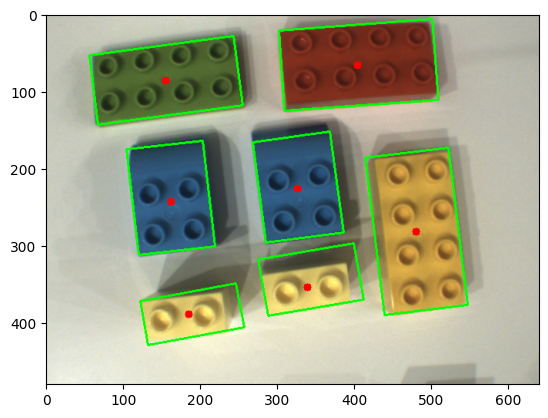


--- kit2 ---


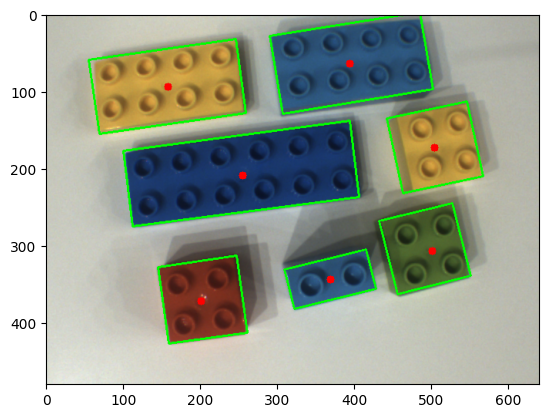


--- kit3 ---


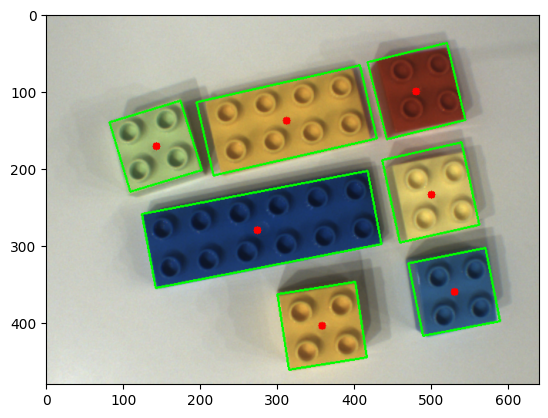

In [60]:

kit1 = cv2.imread(os.path.join(dataset_path, "Kit", "kit1.png"))
kit2 = cv2.imread(os.path.join(dataset_path, "Kit", "kit2.png"))
kit3 = cv2.imread(os.path.join(dataset_path, "Kit", "kit3.png"))

kits = [
    ("kit1", kit1),
    ("kit2", kit2),
    ("kit3", kit3)
]

for name, n in kits:
  print(f"\n--- {name} ---")

  hsv = cv2.cvtColor(n, cv2.COLOR_BGR2HSV)

  # máscara para remover fundo branco/sombra
  mask = cv2.inRange(hsv, (0, 90, 90), (179, 255, 255))
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9,9), np.uint8))
  mask = cv2.erode(mask, np.ones((3,3), np.uint8), iterations=1)
  #plt.imshow(mask, cmap='gray')
  #plt.show()

  #Contours
  contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  for cnt in contours:
    # bounding box ROTACIONADA (melhor)
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.int32(box)

    # centróide
    M = cv2.moments(cnt)
    if M["m00"] != 0:
      cx = int(M["m10"] / M["m00"])
      cy = int(M["m01"] / M["m00"])
    else:
      continue

    # desenhar
    cv2.drawContours(n, [box], 0, (0,255,0), 2)
    cv2.circle(n, (cx, cy), 5, (0,0,255), -1)

  n = cv2.cvtColor(n, cv2.COLOR_BGR2RGB)
  plt.imshow(n, cmap='gray')
  plt.show()



**(b) Count the number of bricks by size and color for all images. Show the result in a table similar to Table 3.**

In [61]:
ImageA_kit = cv2.imread(os.path.join(dataset_path, "Kit", "ImageA_kit.png"))
ImageB_kit = cv2.imread(os.path.join(dataset_path, "Kit", "ImageB_kit.png"))
ImageC_kit = cv2.imread(os.path.join(dataset_path, "Kit", "ImageC_kit.png"))



In [62]:

def count_sizes_colors(image, image_name):

  img_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
  count, masks, white_boxes = count_by_color(image) #count é um dicionário cor : numero

  results = []

  real_areas = {
      "2x1": 32*15, #480 mm^2
      "2x2": 32*32, #1024 mm^2
      "2x4": 32*64, #2048 mm^2
      "2x6": 32*95, #3040 mm^2
      "R2x2": 32*47 #1504 mm^2
  }


  for color, mask in masks.items(): #masks : color -> mask
    #print(f"\n--- {color} ---")
    if color == "white":
            continue  # branco tratado separadamente

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


    sizes = {k: {"px": [], "mm": []} for k in real_areas.keys()}

    debug_img = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    for i, cnt in enumerate(contours):

        # bounding box ROTACIONADA (melhor)
        rect = cv2.minAreaRect(cnt)
        (w, h) = rect[1]
        area_px = w * h

        box = cv2.boxPoints(rect)
        box = np.int32(box)


        #area_px = cv2.contourArea(cnt)
        if area_px < 500: # Changed 'area' to 'area_px'
            continue

          # área em mm
        area_mm = area_px * (scale**2) # Changed 'area' to 'area_px'

          # classificação
        best_match = min(real_areas, key=lambda k: abs(area_mm - real_areas[k]))
        if (w > 50 and w < 85):
          best_match = "2x1"
        if (h > 50 and h < 85):
          best_match = "2x1"
        sizes[best_match]["px"].append(area_px)
        sizes[best_match]["mm"].append(area_mm)


          # centróide
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0

          # desenhar
        cv2.drawContours(debug_img, [box], 0, (0,255,0), 2)
        cv2.circle(debug_img, (cx, cy), 5, (0,0,255), -1)

   # plt.imshow(debug_img, cmap='gray')
   # plt.title(color)
   # plt.show()

    for size, data in sizes.items():

      current_areas_mm = np.array(data["mm"])
      current_areas_px = np.array(data["px"])

      if len(current_areas_mm) == 0:
        continue
      else:
        avg_mm = np.mean(current_areas_mm)
        avg_px = np.mean(current_areas_px)
        std_mm = np.std(current_areas_mm)

      results.append({
          "Image": image_name,
          "Size": size,
          "Color": color,
          "Quantity": len(current_areas_mm)
      })

      #print(f"{size}:")
      #print(f"  Avg px: {avg_px:.2f}")
      #print(f"  Avg mm: {avg_mm:.2f}")
      #print(f"  Std mm: {std_mm:.2f}")
      #print(f"  Number of bricks: {len(current_areas_mm)}")

      ############################## WHITE #####################
    sizes = {k: {"px": [], "mm": []} for k in real_areas.keys()}

    for (x_min, y_min, x_max, y_max) in white_boxes:

        width = x_max - x_min
        height = y_max - y_min

        area_px = width * height
        area_mm = area_px * (scale**2)

        best_match = min(real_areas, key=lambda k: abs(area_mm - real_areas[k]))

        sizes[best_match]["px"].append(area_px)
        sizes[best_match]["mm"].append(area_mm)

    # guardar resultados do branco
    for size, data in sizes.items():

        if len(data["mm"]) == 0:
            continue

        results.append({
            "Image": image_name,
            "Size": size,
            "Color": "white",
            "Quantity": len(data["mm"])
        })

  return results


Color masks obtained from the function **count_by_color** were used to isolate bricks of each color. For each mask, contours were extracted and brick sizes were determined using the same method as in **count_sizes_isolated**, based on area comparison with predefined values. The number of bricks was then counted for each size and color.

In [63]:
images = [
    ("imageA", ImageA_kit),
    ("imageB", ImageB_kit),
    ("imageC", ImageC_kit),
    ("kit1", kit1),
    ("kit2", kit2),
    ("kit3", kit3)
]

all_results = []
for name, k in images:
  #print(f"\n--- {name} ---")
  all_results += count_sizes_colors(k, name)

  df = pd.DataFrame(all_results)

  size_order = ["2x1", "2x2", "R2x2", "2x4", "2x6"]

df["Size"] = pd.Categorical(df["Size"], categories=size_order, ordered=True)

df = df.sort_values(by=["Image", "Size", "Color"])
df_table = df.set_index(["Image", "Size", "Color"]).sort_index()
print(df_table)

                    Quantity
Image  Size Color           
imageA 2x1  yellow         2
       R2x2 blue           2
       2x4  green          1
            red            1
            yellow         1
imageB 2x2  blue           1
            green          1
            red            1
            yellow         2
       2x4  yellow         1
       2x6  blue           1
imageC 2x1  blue           1
       2x2  green          1
            red            1
            yellow         1
       2x4  blue           1
            yellow         1
       2x6  blue           1
kit1   2x1  yellow         2
       R2x2 blue           2
       2x4  green          1
            red            1
            yellow         1
kit2   2x1  blue           1
       2x2  green          1
            red            1
            yellow         1
       2x4  blue           1
            yellow         1
       2x6  blue           1
kit3   2x2  blue           1
            green          1
            re

**c) Which pre-defined kit corresponds to which image?**

To determine which predefined kit corresponds to each image, the number of bricks was compared based on their size and color. For each image and each kit, the data was filtered to include only the attributes Size, Color, and Quantity.

The resulting data was sorted to ensure a consistent ordering, allowing a direct comparison between datasets. A match was identified when the image and a kit had exactly the same distribution of bricks across all sizes and colors.

When this condition was satisfied, the corresponding kit was assigned to the image.

In [64]:
kits = ["kit1", "kit2", "kit3"]
images = ["imageA", "imageB", "imageC"]

for img in images:

    df_img = df[df["Image"] == img][["Size", "Color", "Quantity"]]
    df_img = df_img.sort_values(by=["Size", "Color"]).reset_index(drop=True)

    #print(f"\n--- {img} ---")
    #print(df_img)

    for kit in kits:

        df_kit = df[df["Image"] == kit][["Size", "Color", "Quantity"]]
        df_kit = df_kit.sort_values(by=["Size", "Color"]).reset_index(drop=True)

        # comparar diretamente
        if df_img.equals(df_kit):
            print(f"{img} -> {kit}")

imageA -> kit1
imageB -> kit3
imageC -> kit2


**d) Provide some recommendations that the Lego factory should take into consideration to improve the performance of the sorting process based on image processing**

The imaging setup should avoid backgrounds with similar colors to the bricks, such as white backgrounds with white pieces. Lighting should be uniform to reduce shadows and reflections. Calibration should be performed to ensure accurate size and color measurements. Finally, controlling exposure and white balance helps maintain consistent image quality.

# **4- Fault Images**

**Using the Fault image set, assign each image to its corresponding kit or classify it as a Faulty kit. A kit is deemed faulty if it does not match any of the predefined kits, either due to a missing or surplus number of parts, or the inclusion of bricks that are not specified for that kit. In the case of a fault, automatically identify the cause.**

In [65]:
ImageA_fault = cv2.imread(os.path.join(dataset_path, "Fault", "ImageA_fault.png"))
ImageB_fault = cv2.imread(os.path.join(dataset_path, "Fault", "ImageB_fault.png"))
ImageC_fault = cv2.imread(os.path.join(dataset_path, "Fault", "ImageC_fault.png"))
ImageD_fault = cv2.imread(os.path.join(dataset_path, "Fault", "imageD_fault.png"))
ImageE_fault = cv2.imread(os.path.join(dataset_path, "Fault", "ImageE_fault.png"))
ImageF_fault = cv2.imread(os.path.join(dataset_path, "Fault", "ImageF_fault.png"))

kitA = cv2.imread(os.path.join(dataset_path, "Fault", "kitA.png"))
kitB = cv2.imread(os.path.join(dataset_path, "Fault", "kitB.png"))
kitC = cv2.imread(os.path.join(dataset_path, "Fault", "kitC.png"))

images = {
    "imageA": ImageA_fault,
    "imageB": ImageB_fault,
    "imageC": ImageC_fault,
    "imageD": ImageD_fault,
    "imageE": ImageE_fault,
    "imageF": ImageF_fault
}

kits = {
    "kitA": kitA,
    "kitB": kitB,
    "kitC": kitC
}

To classify each image from the fault dataset, the number of bricks per size and color was first computed using the previously defined **count_sizes_colors** function. The results for all images and predefined kits were stored in separate dataframes, ensuring that the data was consistently sorted by size and color.

Each image was then compared against all predefined kits. If an exact match was found, meaning the same number of bricks for every size and color, the image was assigned to that kit.

If no exact match was found, the image was classified as a faulty kit. In this case, both the image and each kit were converted into dictionaries mapping (size, color) pairs to their respective quantities. This allowed a detailed comparison of all possible brick types.

For each kit, the total difference in quantities was computed by summing the absolute differences across all size–color combinations. The kit with the smallest total difference was considered the closest match.

Finally, the cause of the fault was identified by analyzing these differences. If the image contained more bricks than expected, they were labeled as extra. If it contained fewer, they were labeled as missing. This provided a clear explanation of the discrepancy for each faulty image.

In [66]:
df_fault_list = []
df_kit_list = []

for name, img in images.items():
    results = count_sizes_colors(img, name)
    df_temp = pd.DataFrame(results)
    df_temp = df_temp.sort_values(by=["Size", "Color"]).reset_index(drop=True)
    df_fault_list.append(df_temp)
df_fault = pd.concat(df_fault_list)
#print(df_fault)

for name, kit in kits.items():
    results = count_sizes_colors(kit, name)
    df_kit_temp = pd.DataFrame(results)
    df_kit_temp = df_kit_temp.sort_values(by=["Size", "Color"]).reset_index(drop=True)
    df_kit_list.append(df_kit_temp)
df_kit = pd.concat(df_kit_list)
#print(df_kit)

###########  COMPARAR PEÇAS #######################

for name_img, img in images.items():
    print("\n")
    df_img = df_fault[df_fault["Image"] == name_img][["Size", "Color", "Quantity"]]
    matched = False

    #print(f"\n--- {name_img} ---")
    #print(df_img)

    for kit_name, kit in kits.items():

        df_kit_current = df_kit[df_kit["Image"] == kit_name][["Size", "Color", "Quantity"]]


        #print(f"\n--- {kit_name} ---")
        #print(df_kit_current)
        # comparar diretamente
        if df_img.equals(df_kit_current):
            print(f"{name_img} -> {kit_name}")
            matched = True
            break

    if not matched:
      img_dict = {
       (row["Size"], row["Color"]): row["Quantity"]
       for _, row in df_img.iterrows()
    }

      best_kit = None
      best_diff = float("inf")
      best_diffs = None

      for kit_name, kit in kits.items():

              df_kit_current = df_kit[df_kit["Image"] == kit_name][["Size", "Color", "Quantity"]]

              kit_dict = {
                  (row["Size"], row["Color"]): row["Quantity"]
                  for _, row in df_kit_current.iterrows()
              }

              all_keys = set(img_dict.keys()) | set(kit_dict.keys()) #PEÇAS TOTAIS (imagem + 1 kit)

              total_diff = 0
              diffs = []

              for key in all_keys: #percorremos as peças totais (imagem + 1 kit)
                  img_q = img_dict.get(key, 0)
                  kit_q = kit_dict.get(key, 0)

                  diff = abs(img_q - kit_q)
                  total_diff += diff

                  if diff > 0:
                      diffs.append((key, img_q, kit_q))

              if total_diff < best_diff:
                  best_diff = total_diff
                  best_kit = kit_name
                  best_diffs = diffs

      print(f"{name_img} -> FAULTY (mais próximo: {best_kit})")

      for (size, color), img_q, kit_q in best_diffs:

        if img_q > kit_q:
          print(f"  EXTRA: {size} {color} ({img_q - kit_q})")

        elif img_q < kit_q:
          print(f"  MISSING: {size} {color} ({kit_q - img_q})")





imageA -> FAULTY (mais próximo: kitB)
  EXTRA: 2x2 white (1)
  MISSING: R2x2 blue (1)


imageB -> kitA


imageC -> FAULTY (mais próximo: kitC)
  MISSING: 2x6 blue (1)
  EXTRA: 2x2 blue (2)


imageD -> kitC


imageE -> kitB


imageF -> FAULTY (mais próximo: kitA)
  EXTRA: 2x1 blue (1)
  MISSING: 2x1 yellow (1)
